## Customer Segmentation Analysis

Customer churn tidak hanya dipengaruhi oleh satu faktor tunggal, tetapi merupakan hasil interaksi berbagai karakteristik pelanggan seperti lama berlangganan, tingkat pengeluaran, penggunaan layanan, dan jenis kontrak. Oleh karena itu, memahami **segmen pelanggan yang memiliki risiko churn tinggi** menjadi langkah penting dalam merancang strategi retensi yang efektif.

Pada notebook ini dilakukan **analisis segmentasi pelanggan** untuk mengidentifikasi pola churn berdasarkan beberapa dimensi utama, yaitu:

* **Tenure Segment** – untuk melihat apakah pelanggan baru atau pelanggan lama memiliki risiko churn yang lebih tinggi.
* **Spending Segment** – untuk mengetahui apakah pelanggan dengan pengeluaran tinggi lebih loyal atau justru lebih rentan churn.
* **Service Usage** – untuk menganalisis hubungan antara jumlah layanan yang digunakan dengan tingkat churn.
* **Contract Type Risk** – untuk mengidentifikasi risiko churn pada pelanggan dengan kontrak **month-to-month** dibandingkan kontrak jangka panjang.
* **Customer Lifetime Value (CLV) (Proxy)** – untuk melihat hubungan antara nilai ekonomi pelanggan dengan probabilitas churn. 
Pada dataset ini, CLV tidak dihitung menggunakan model prediktif CLV yang kompleks, melainkan menggunakan pendekatan sederhana berbasis nilai historis pelanggan. Oleh karena itu, metrik ini digunakan sebagai **indikator proxy nilai pelanggan**, bukan estimasi CLV jangka panjang yang sesungguhnya.
* **Revenue at Risk** – untuk mengestimasi potensi kerugian pendapatan akibat pelanggan yang churn.

Melalui analisis ini, tujuan utama adalah:

1. Mengidentifikasi **segmen pelanggan dengan risiko churn tertinggi**.
2. Mengukur **potensi kerugian revenue akibat churn**.
3. Memberikan **insight berbasis data** yang dapat digunakan untuk merancang strategi **customer retention yang lebih terarah**.

Dataset yang digunakan berasal dari view **`churn_feature_dataset`**. View ini mencakup sejumlah fitur hasil transformasi seperti tenure bucket, spending segment, service count, serta metrik bisnis seperti CLV dan revenue at risk untuk mendukung analisis segmentasi pelanggan.

In [1]:
# Import libraries & data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
from scr.database import get_engine

engine = get_engine()

query = "SELECT * FROM churn_feature_dataset;"
df = pd.read_sql(query, engine)

df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,churn,tenure_bucket,contract_name,payment_name,internet_service,monthly_charges,total_charges,paperless_billing,spending_segment,service_count,contract_risk_flag,clv,revenue_at_risk
0,7590-vhveg,female,False,True,False,1,False,0–5 months,month-to-month,electronic check,dsl,29.85,29.85,True,Low Spender,1,1,29.85,0.0
1,5575-gnvde,male,False,False,False,34,False,25+ months,one year,mailed check,dsl,56.95,1889.50,False,Mid Spender,3,0,1936.30,0.0
2,3668-qpybk,male,False,False,False,2,True,0–5 months,month-to-month,mailed check,dsl,53.85,108.15,True,Mid Spender,3,1,107.70,646.2
3,7795-cfocw,male,False,False,False,45,False,25+ months,one year,bank transfer (automatic),dsl,42.30,1840.75,False,Mid Spender,3,0,1903.50,0.0
4,9237-hqitu,female,False,False,False,2,True,0–5 months,month-to-month,electronic check,fiber optic,70.70,151.65,True,High Spender,1,1,141.40,848.4


**Customer dengan lama berlangganan berapa yang paling berisiko churn?**

In [2]:
tenure_analysis = (
    df.groupby("tenure_bucket")
      .agg(
          total_customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          avg_clv=("clv", "mean")
      )
      .sort_values("churn_rate", ascending=False)
)

tenure_analysis

,total_customers,churn_rate,avg_clv
tenure_bucket,,,
0–5 months,1371,0.542670,126.905252
6–12 months,815,0.359509,524.034785
13–24 months,1024,0.287109,1127.041943
25+ months,3833,0.140360,3730.739643


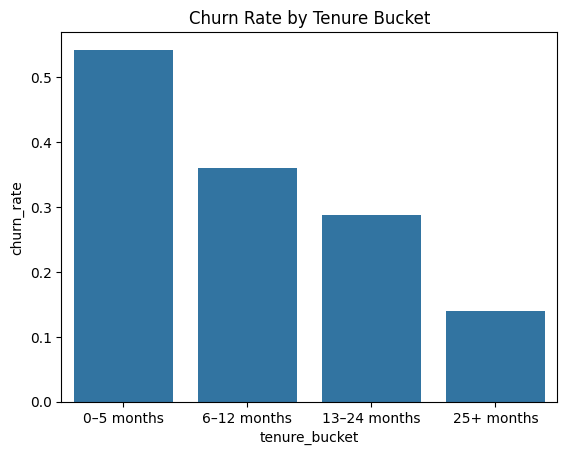

In [3]:
plt.figure()
sns.barplot(data=tenure_analysis.reset_index(),
            x="tenure_bucket",
            y="churn_rate")
plt.title("Churn Rate by Tenure Bucket")
plt.show()

**Insight**

Early-stage customer (0–5 bulan) memiliki churn rate tertinggi, menunjukkan masalah di fase onboarding.
Namun, meskipun churn rate pada customer 25+ bulan lebih rendah, basis customer yang besar membuat kontribusi churn absolutnya tetap signifikan.

**Apakah customer dengan pengeluaran tinggi lebih loyal atau justru lebih cepat churn?**

In [4]:
spending_analysis = (
    df.groupby("spending_segment")
      .agg(
          total_customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          avg_monthly=("monthly_charges", "mean"),
          total_revenue=("monthly_charges", "sum")
      )
      .sort_values("total_revenue", ascending=False)
)

spending_analysis


,total_customers,churn_rate,avg_monthly,total_revenue
spending_segment,,,,
High Spender,3583,0.353614,90.232291,323302.30
Mid Spender,1623,0.239680,55.951602,90809.45
Low Spender,1837,0.115950,22.866004,42004.85


**Insight**

Segmen High Spender menyumbang revenue terbesar (323K) namun memiliki churn rate tertinggi (35%). Ini menunjukkan bahwa customer paling profitable juga merupakan segmen paling berisiko, sehingga strategi retention harus difokuskan pada High Spender untuk mengurangi potensi revenue loss.

**Apakah semakin banyak layanan yang digunakan, semakin kecil kemungkinan churn?**

In [5]:
service_analysis = (
    df.groupby("service_count")
      .agg(
          total_customers=("customer_id", "count"),
          churn_rate=("churn", "mean")
      )
)

service_analysis

,total_customers,churn_rate
service_count,,
0,80,0.437500
1,1701,0.211052
2,1188,0.328283
3,965,0.364767
4,922,0.313449
5,908,0.255507
6,676,0.224852
7,395,0.124051
8,208,0.052885


**Insight**

Terlihat bahwa semakin banyak layanan yang digunakan, semakin rendah tingkat churn. Pelanggan dengan 7–8 layanan memiliki churn rate yang sangat rendah (sekitar 5–12%), menunjukkan adanya customer stickiness yang lebih kuat. Sebaliknya, pelanggan dengan 0 layanan memiliki churn rate tertinggi (43.7%). Hal ini mengindikasikan kemungkinan bahwa pelanggan tersebut hanya memiliki akun tanpa benar-benar menggunakan layanan tambahan, sehingga tingkat engagement cenderung rendah dan lebih rentan untuk churn.

**Seberapa besar risiko churn pada kontrak month-to-month?**

In [6]:
contract_analysis = (
    df.groupby("contract_risk_flag")
      .agg(
          total_customers=("customer_id", "count"),
          churn_rate=("churn", "mean"),
          avg_clv=("clv", "mean")
      )
)

contract_analysis


,total_customers,churn_rate,avg_clv
contract_risk_flag,,,
0,3168,0.067551,3392.012532
1,3875,0.427097,1370.115032


**Insight**

Customer dengan kontrak month-to-month memiliki risiko churn yang sangat tinggi, dengan churn rate sebesar 42,7%, jauh di atas pelanggan non-risk yang hanya 6,7%. Selain itu, rata-rata CLV pada segmen ini juga jauh lebih rendah (1.370 vs 3.392), menunjukkan bahwa mereka tidak hanya lebih cepat churn, tetapi juga memberikan nilai jangka panjang yang lebih kecil.

**Apakah customer dengan historical customer value (CLV proxy) tinggi cenderung churn?**

In [7]:
clv_analysis = (
    df.groupby("churn")
      .agg(
          avg_clv=("clv", "mean"),
          total_clv=("clv", "sum")
      )
)

clv_analysis

,avg_clv,total_clv
churn,,
False,2549.770883,13192514.55
True,1531.608828,2862576.90


**Insight**

Customer dengan historical customer value (CLV proxy) tinggi menunjukkan tingkat retensi yang lebih baik dibandingkan customer dengan CLV rendah. Hal ini mengindikasikan bahwa nilai ekonomi customer berkorelasi negatif dengan probabilitas churn. Strategi retensi sebaiknya difokuskan pada peningkatan CLV customer low-value sebelum mereka churn.

**Berapa estimasi revenue tahunan yang hilang akibat churn?**

In [8]:
total_revenue_risk = df["revenue_at_risk"].sum()
avg_revenue_risk = df[df["churn"] == 1]["revenue_at_risk"].mean()

print("Total Revenue at Risk:", round(total_revenue_risk,2))
print("Avg Revenue per Churned Customer:", round(avg_revenue_risk,2))

Total Revenue at Risk: 1669570.2
Avg Revenue per Churned Customer: 893.3


**Insight**

Perusahaan berpotensi kehilangan ±1.67 juta revenue tahunan akibat churn. Setiap pelanggan yang churn menyumbang rata-rata sekitar 893 dalam revenue per tahun. Strategi retention yang terarah pada pelanggan bernilai tinggi dapat secara signifikan mengurangi potensi kehilangan revenue dan meningkatkan profitabilitas jangka panjang.

**Apakah segmen pelanggan dengan tingkat pengeluaran lebih tinggi memiliki revenue at risk yang lebih besar?**

In [9]:
risk_segment = (
    df.groupby("spending_segment")["revenue_at_risk"]
    .sum()
)

risk_segment

spending_segment
High Spender    1349892.0
Low Spender       64118.4
Mid Spender      255559.8
Name: revenue_at_risk, dtype: float64

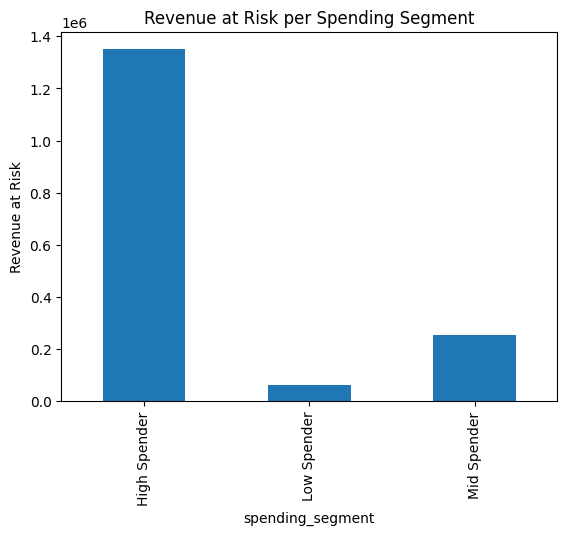

In [10]:
risk_segment = (
    df.groupby("spending_segment")["revenue_at_risk"]
    .sum()
)

risk_segment.plot(kind="bar")
plt.title("Revenue at Risk per Spending Segment")
plt.ylabel("Revenue at Risk")
plt.show()

**Insight**

High Spender menyumbang revenue at risk terbesar (±1,35 juta), jauh melampaui Mid dan Low Spender. Artinya, kehilangan sedikit pelanggan High Spender saja berdampak besar pada potensi kerugian pendapatan, sehingga segmen ini perlu menjadi prioritas dalam strategi retensi.